# Détection de l'occupation à partir du CO2 — OQAI CNL1

**Question posée** : peut-on retrouver la présence des occupants à partir du
seul signal CO2 ?

Contrairement à une approche par clustering (qui décrit des types de journées
sans jamais confronter le résultat à la réalité), on dispose ici d'une
**vérité terrain** : le *semainier* indique, pour chaque logement, chaque
tranche de 10 minutes et chaque occupant, la pièce où il se trouve. La même
résolution temporelle que le CO2.

Cela permet de poser le problème en **apprentissage supervisé** et de mesurer
objectivement ce que le signal permet — ou ne permet pas — de retrouver.

**Démarche :**
1. Construction du jeu de données aligné CO2 × semainier
2. Relation entre signal et présence, **sans modèle**
3. Modèle de détection de l'occupation
4. Ce que le modèle a appris
5. Typologie des journées sur variables interprétables


## 1. Construction du jeu de données

Deux sources à croiser :

- **CO2** — une mesure toutes les 10 minutes, soit 144 points par journée.
- **Semainier** — pour chaque occupant, la pièce occupée sur les mêmes
  144 tranches, déclarée sur 7 jours.

On ne retient que les journées où **les deux sources sont complètes**.


In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 60)

DATA = '../data/cln1/Raw'

SG_WINDOW, SG_POLY = 13, 2      # lissage Savitzky-Golay (13 pts ≈ 2h10, ordre 2)
IDN_EXTERIEUR = 90              # LISTE_PIECE : 90 = EXT0 « Extérieur »
hours = np.arange(144) / 6      # grille horaire commune (0 à 24 h)


In [ ]:
# ── CO2 : dérivée sur la série continue, puis découpage en journées complètes
co2 = pd.read_csv(f'{DATA}/Mesures_Confort_Dynamique/CNL1_SERIE_CO2.txt', sep='\t',
                  encoding='latin1', usecols=['CODELIEU', 'DATE_HEURE', 'VALEUR'],
                  parse_dates=['DATE_HEURE'])
co2['VALEUR'] = pd.to_numeric(co2['VALEUR'], errors='coerce')
co2 = co2.dropna(subset=['VALEUR'])
co2['DATE'] = co2['DATE_HEURE'].dt.normalize()

# La dérivée est calculée sur la série CONTINUE de chaque logement : un calcul
# journée par journée créerait un artefact à minuit, le filtre ayant besoin de
# points de part et d'autre de chaque instant.
co2 = co2.sort_values(['CODELIEU', 'DATE_HEURE'])
co2['deriv'] = (co2.groupby('CODELIEU')['VALEUR']
                .transform(lambda x: savgol_filter(x, SG_WINDOW, SG_POLY,
                                                   deriv=1, delta=1/6)))

n = co2.groupby(['CODELIEU', 'DATE'])['VALEUR'].transform('size')
co2 = co2[n == 144].copy()
co2['tranche'] = co2.groupby(['CODELIEU', 'DATE']).cumcount()   # 0..143

print(f'{co2.groupby(["CODELIEU", "DATE"]).ngroups:,} journées CO2 complètes '
      f'— {co2["CODELIEU"].nunique()} logements')


3,012 journées CO2 complètes — 513 logements


In [ ]:
# ── Semainier : présence déclarée par occupant et par tranche de 10 min
sem = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_SEMAINIER_DATA.txt',
                  sep='\t', encoding='latin1')
sem['DATE'] = pd.to_datetime(sem['DATE'], format='%d/%m/%Y')
sem = sem[sem['CODE_HEURE'].str.startswith('V_1')].copy()   # tranches du jour
sem['tranche'] = sem['CODE_HEURE'].str[2:].astype(int) - 1001

# Pièce où se trouve le capteur CO2 de chaque logement
cap = (pd.read_csv(f'{DATA}/Mesures_Confort_Dynamique/CNL1_SERIE_CO2.txt', sep='\t',
                   encoding='latin1', usecols=['CODELIEU', 'IDN_PIECE'])
       .groupby('CODELIEU')['IDN_PIECE'].first())
sem['piece_capteur'] = sem['CODELIEU'].map(cap)

# ── Traitement des déclarations manquantes ──
# 8.2 % des cases du semainier ne sont pas renseignées. Une comparaison directe
# (IDN_PIECE == piece_capteur) renverrait False pour ces cases, ce qui reviendrait
# à déclarer l'occupant ABSENT alors que sa position est simplement INCONNUE.
# On distingue donc les deux cas, et les tranches sans aucune information seront
# écartées plus bas plutôt que comptées comme des absences.
renseigne = sem['IDN_PIECE'].notna()
sem['dans_piece']    = renseigne & (sem['IDN_PIECE'] == sem['piece_capteur'])
sem['dans_logement'] = renseigne & (sem['IDN_PIECE'] != IDN_EXTERIEUR)

print(f'Déclarations manquantes : {(~renseigne).sum():,} / {len(sem):,} '
      f'({100*(~renseigne).mean():.1f}%)')

# Agrégation par tranche : « au moins un occupant présent ».
# n_renseignes = nombre d'occupants dont la position est connue sur cette tranche ;
# une tranche où il vaut 0 ne permet aucune conclusion.
presence = (sem.groupby(['CODELIEU', 'DATE', 'tranche'])
            .agg(dans_piece=('dans_piece', 'any'),
                 dans_logement=('dans_logement', 'any'),
                 n_occ_piece=('dans_piece', 'sum'),
                 n_declares=('IDN_PIECE', 'size'),
                 n_renseignes=(renseigne.name if renseigne.name else 'IDN_PIECE',
                               'count'))
            .reset_index())
presence['n_manquants'] = presence['n_declares'] - presence['n_renseignes']

print(f'{presence.groupby(["CODELIEU", "DATE"]).ngroups:,} journées de semainier '
      f'— {presence["CODELIEU"].nunique()} logements')
print(f'Tranches sans aucune position connue : '
      f'{(presence["n_renseignes"] == 0).sum():,} '
      f'({100*(presence["n_renseignes"] == 0).mean():.1f}%)')


Déclarations manquantes : 113,888 / 1,386,000 (8.2%)
3,642 journées de semainier — 519 logements
Tranches sans aucune position connue : 30,249 (5.8%)


In [ ]:
# ── Croisement : une ligne = un logement × une journée × une tranche de 10 min
df = co2[['CODELIEU', 'DATE', 'tranche', 'DATE_HEURE', 'VALEUR', 'deriv']].merge(
    presence, on=['CODELIEU', 'DATE', 'tranche'], how='inner')

def bilan(d, etape):
    return {'étape': etape, 'observations': len(d),
            'journées': d.groupby(['CODELIEU', 'DATE']).ngroups,
            'logements': d['CODELIEU'].nunique()}

suivi = [bilan(df, 'Croisement CO2 × semainier')]

# 1. Journées saturées (>= 6000 ppm : plage du capteur dépassée)
sat = df.groupby(['CODELIEU', 'DATE'])['VALEUR'].transform('max') >= 6000
df = df[~sat]
suivi.append(bilan(df, 'Sans journées saturées'))

# 2. Semainier intégralement renseigné.
#    Une tranche où un seul occupant n'a pas rempli sa case est écartée : si l'on
#    la conservait, elle serait comptée « personne dans la pièce » alors que
#    l'occupant manquant pourrait précisément s'y trouver. Ce biais ne créerait
#    que de fausses absences — autant le supprimer entièrement.
df = df[df['n_manquants'] == 0]
suivi.append(bilan(df, 'Semainier sans aucune valeur manquante'))

df['heure'] = df['tranche'] / 6

suivi = pd.DataFrame(suivi)
suivi['obs. perdues'] = -suivi['observations'].diff().fillna(0).astype(int)
suivi['log. perdus']  = -suivi['logements'].diff().fillna(0).astype(int)
display(suivi.set_index('étape'))

# Contrôle : plus aucune information manquante dans le jeu retenu
assert (df['n_manquants'] == 0).all(), 'valeurs manquantes résiduelles'
print('Contrôle : aucune position d\'occupant manquante dans le jeu final ✓')
print(f'  positions déclarées et connues : {int(df["n_renseignes"].sum()):,}')

print(f'\nJeu final : {len(df):,} observations · '
      f'{df.groupby(["CODELIEU", "DATE"]).ngroups:,} journées · '
      f'{df["CODELIEU"].nunique()} logements')
print(f'\nPrésence dans la pièce du capteur : {df["dans_piece"].mean()*100:.1f}%')
print(f'Présence dans le logement          : {df["dans_logement"].mean()*100:.1f}%')


,observations,journées,logements,obs. perdues,log. perdus
étape,,,,,
Croisement CO2 × semainier,391248,2717,471,0,0
Sans journées saturées,389952,2708,471,1296,0
Semainier sans aucune valeur manquante,342698,2488,451,47254,20


Contrôle : aucune position d'occupant manquante dans le jeu final ✓
  positions déclarées et connues : 895,460

Jeu final : 342,698 observations · 2,488 journées · 451 logements

Présence dans la pièce du capteur : 41.4%
Présence dans le logement          : 79.2%


**Sur le choix de la cible** — deux définitions sont disponibles :

- `dans_piece` : un occupant est **dans la pièce du capteur**. C'est ce que le
  CO2 mesure le plus directement, mais la déclaration est plus exigeante.
- `dans_logement` : un occupant est **quelque part dans le logement**. Plus
  robuste aux erreurs de déclaration de pièce, mais le lien avec le signal est
  indirect — le CO2 d'une chambre réagit peu à quelqu'un resté au salon.

Le capteur étant en chambre dans 95 % des logements, `dans_piece` correspond
largement à « quelqu'un dort ici ». On retient cette cible, plus proche du
signal, et on vérifiera l'autre en comparaison.

**Sur les déclarations manquantes** — 8.2 % des cases du semainier ne sont pas
renseignées. Une comparaison directe (`IDN_PIECE == piece_capteur`) renverrait
`False` pour ces cases et les compterait comme des **absences**, alors que la
position y est seulement **inconnue**.

Le parti retenu est le plus strict : ne conserver que les tranches où **tous**
les occupants ont renseigné leur position. Une tranche partiellement remplie
serait en effet codée « personne dans la pièce » alors qu'un occupant manquant
pourrait s'y trouver — un biais qui ne fabrique que de fausses absences.

Cette exigence coûte peu (voir le tableau ci-dessus) et garantit une vérité
terrain sans ambiguïté : **aucune valeur manquante ne subsiste** dans le jeu
utilisé, ni du côté du CO2 (les journées incomplètes sont écartées par la
contrainte des 144 points), ni du côté du semainier.


## 2. Le signal distingue-t-il la présence ? — sans modèle

Avant tout modèle, une vérification élémentaire : les valeurs de CO2 et de
dérivée sont-elles **différentes** selon que quelqu'un est présent ou non ?

Si les distributions se superposent, aucun modèle ne pourra séparer les deux
cas, et il faudra le constater ici plutôt qu'après coup.


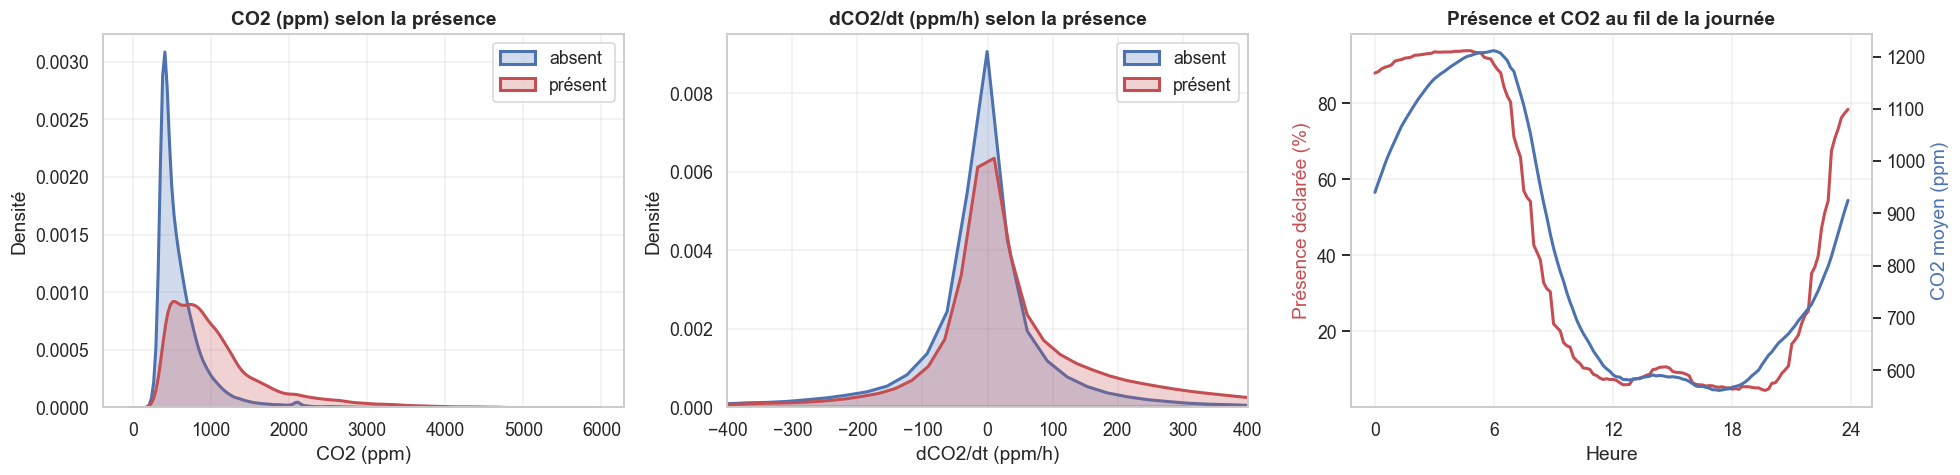

VALEUR               deriv              
              mean median    std  mean median    std
dans_piece                                          
False        626.4  504.0  396.9 -24.6   -3.6  196.3
True        1109.5  909.0  716.8  34.8    8.2  201.4

In [ ]:
CIBLE = 'dans_piece'

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

for ax, (col, label) in zip(axes, [('VALEUR', 'CO2 (ppm)'),
                                   ('deriv', 'dCO2/dt (ppm/h)')]):
    for val, lab, color in [(False, 'absent', '#4C72B0'), (True, 'présent', '#C44E52')]:
        sns.kdeplot(df.loc[df[CIBLE] == val, col], ax=ax, label=lab,
                    color=color, fill=True, alpha=0.25, lw=2)
    ax.set_xlabel(label); ax.set_ylabel('Densité')
    ax.set_title(f'{label} selon la présence', fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)
axes[1].set_xlim(-400, 400)

# Taux de présence et CO2 moyen au fil de la journée
prof = df.groupby('heure').agg(taux=(CIBLE, 'mean'), co2=('VALEUR', 'mean'))
ax = axes[2]
ax.plot(prof.index, prof['taux'] * 100, color='#C44E52', lw=2, label='taux de présence')
ax.set_xlabel('Heure'); ax.set_ylabel('Présence déclarée (%)', color='#C44E52')
ax.set_xticks([0, 6, 12, 18, 24]); ax.grid(True, alpha=0.3)
ax2 = ax.twinx()
ax2.plot(prof.index, prof['co2'], color='#4C72B0', lw=2, label='CO2 moyen')
ax2.set_ylabel('CO2 moyen (ppm)', color='#4C72B0'); ax2.grid(False)
ax.set_title('Présence et CO2 au fil de la journée', fontweight='bold')

plt.tight_layout(); plt.show()

stats = df.groupby(CIBLE)[['VALEUR', 'deriv']].agg(['mean', 'median', 'std']).round(1)
display(stats)


In [ ]:
# Pouvoir discriminant de chaque variable, prise seule (AUC)
# 0.5 = aucun pouvoir discriminant · 1.0 = séparation parfaite
from sklearn.metrics import roc_auc_score

# Le CO2 normalisé par logement corrige les écarts de niveau de fond entre
# logements (ventilation, volume) qui masquent l'effet de l'occupation.
stats_log = df.groupby('CODELIEU')['VALEUR'].agg(['mean', 'std'])
df['co2_znorm'] = ((df['VALEUR'] - df['CODELIEU'].map(stats_log['mean']))
                   / df['CODELIEU'].map(stats_log['std']).clip(lower=1e-9))

for var in ['VALEUR', 'co2_znorm', 'deriv']:
    auc = roc_auc_score(df[CIBLE], df[var])
    print(f'{var:<12} AUC = {auc:.3f}   (inversé : {1-auc:.3f})')

print('\nCorrélation avec la présence :')
print(df[['VALEUR', 'co2_znorm', 'deriv']].corrwith(df[CIBLE].astype(int)).round(3).to_string())


VALEUR       AUC = 0.782   (inversé : 0.218)
co2_znorm    AUC = 0.837   (inversé : 0.163)
deriv        AUC = 0.604   (inversé : 0.396)

Corrélation avec la présence :
VALEUR       0.396
co2_znorm    0.541
deriv        0.146


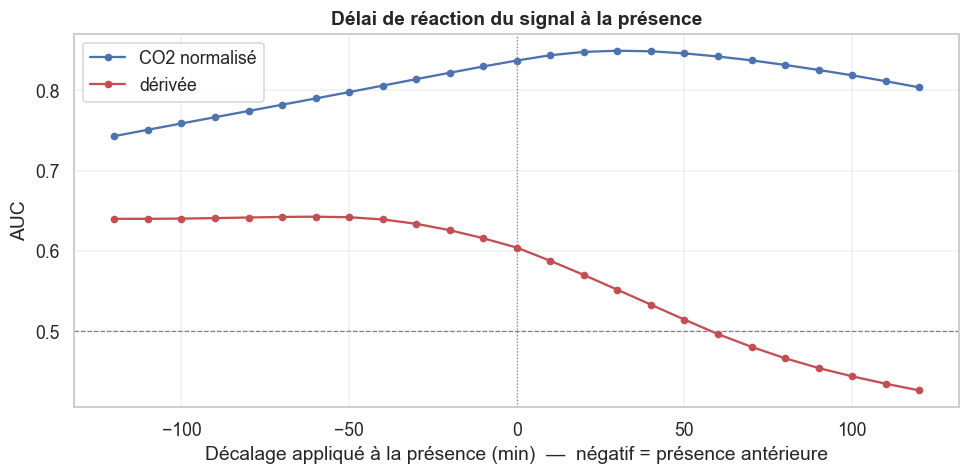

CO2 : AUC maximale 0.849 à +30 min
Dérivée : AUC maximale 0.643 à -60 min


In [ ]:
# Le CO2 réagit avec un délai : quel décalage maximise le lien avec la présence ?
# shift(+k) ramène la présence d'il y a k tranches en face du CO2 actuel : un
# maximum du côté positif signifie donc que le signal reflète l'occupation PASSÉE.
lags = range(-12, 13)   # ± 2 heures, par pas de 10 min
res = []
for lag in lags:
    cible_lag = df.groupby(['CODELIEU', 'DATE'])[CIBLE].shift(lag)
    ok = cible_lag.notna()
    y = cible_lag[ok].astype(int)
    res.append({'lag_min': lag * 10,
                'auc_co2': roc_auc_score(y, df.loc[ok, 'co2_znorm']),
                'auc_deriv': roc_auc_score(y, df.loc[ok, 'deriv'])})
res = pd.DataFrame(res)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(res['lag_min'], res['auc_co2'], marker='o', ms=4, label='CO2 normalisé', color='#4C72B0')
ax.plot(res['lag_min'], res['auc_deriv'], marker='o', ms=4, label='dérivée', color='#C44E52')
ax.axhline(0.5, color='grey', lw=0.8, ls='--')
ax.axvline(0, color='grey', lw=0.8, ls=':')
ax.set_xlabel('Décalage appliqué à la présence (min)
positif : le signal est comparé à la présence passée · négatif : à la présence future')
ax.set_ylabel('AUC'); ax.set_title('Délai de réaction du signal à la présence', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

best = res.loc[res['auc_co2'].idxmax()]
print(f"CO2 : AUC maximale {best['auc_co2']:.3f} à {best['lag_min']:+.0f} min")
best_d = res.loc[res['auc_deriv'].idxmax()]
print(f"Dérivée : AUC maximale {best_d['auc_deriv']:.3f} à {best_d['lag_min']:+.0f} min")


## 3. Modèle de détection

**Précaution sur la découpe train/test** : elle se fait **par logement**, jamais
par journée. Si des journées d'un même logement se retrouvaient des deux côtés,
le modèle apprendrait à reconnaître *ce logement* (son niveau de CO2 habituel,
ses horaires) plutôt que la relation générale entre signal et occupation — et le
score de test serait trompeusement élevé.

**Variables** : uniquement des grandeurs disponibles à l'instant considéré ou
avant, plus l'heure. Les statistiques de normalisation sont calculées **par
logement** (pas par journée), ce qui reste valide pour une analyse a posteriori.


In [ ]:
# ── Construction des variables explicatives
d = df.sort_values(['CODELIEU', 'DATE', 'tranche']).copy()
g = d.groupby(['CODELIEU', 'DATE'])

d['deriv_lisse'] = g['deriv'].transform(
    lambda x: savgol_filter(x, SG_WINDOW, SG_POLY) if len(x) >= SG_WINDOW else x)

# Contexte récent : moyennes glissantes sur 30 min et 1 h (passé uniquement)
for w in (3, 6):
    d[f'co2_moy_{w*10}min']   = g['co2_znorm'].transform(lambda x: x.rolling(w, min_periods=1).mean())
    d[f'deriv_moy_{w*10}min'] = g['deriv'].transform(lambda x: x.rolling(w, min_periods=1).mean())

# Écart au niveau le plus bas de la journée : traduit l'accumulation depuis
# le dernier renouvellement d'air
d['co2_ecart_min'] = d['VALEUR'] - g['VALEUR'].transform('min')

# L'heure est cyclique : minuit et 23h50 doivent être proches, d'où sin/cos
d['heure_sin'] = np.sin(2 * np.pi * d['heure'] / 24)
d['heure_cos'] = np.cos(2 * np.pi * d['heure'] / 24)

FEATURES = ['co2_znorm', 'deriv', 'deriv_lisse',
            'co2_moy_30min', 'co2_moy_60min', 'deriv_moy_30min', 'deriv_moy_60min',
            'co2_ecart_min', 'heure_sin', 'heure_cos']

d = d.dropna(subset=FEATURES + [CIBLE])
print(f'{len(d):,} observations · {len(FEATURES)} variables')
print('Variables :', ', '.join(FEATURES))


342,698 observations · 10 variables
Variables : co2_znorm, deriv, deriv_lisse, co2_moy_30min, co2_moy_60min, deriv_moy_30min, deriv_moy_60min, co2_ecart_min, heure_sin, heure_cos


In [ ]:
# ── Découpe par logement (aucun logement des deux côtés)
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
i_train, i_test = next(gss.split(d, groups=d['CODELIEU']))
train, test = d.iloc[i_train], d.iloc[i_test]

X_train, y_train = train[FEATURES].values, train[CIBLE].astype(int).values
X_test,  y_test  = test[FEATURES].values,  test[CIBLE].astype(int).values

print(f'Entraînement : {len(train):,} obs · {train["CODELIEU"].nunique()} logements')
print(f'Test         : {len(test):,} obs · {test["CODELIEU"].nunique()} logements')
print(f'Logements communs (doit être 0) : '
      f'{len(set(train["CODELIEU"]) & set(test["CODELIEU"]))}')
print(f'\nTaux de présence — entraînement : {y_train.mean()*100:.1f}% · '
      f'test : {y_test.mean()*100:.1f}%')


Entraînement : 239,548 obs · 315 logements
Test         : 103,150 obs · 136 logements
Logements communs (doit être 0) : 0

Taux de présence — entraînement : 40.5% · test : 43.3%


In [ ]:
# ── Trois modèles, du plus simple au plus expressif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, balanced_accuracy_score

modeles = {
    'Référence (classe majoritaire)': DummyClassifier(strategy='most_frequent'),
    'Régression logistique': make_pipeline(StandardScaler(),
                                           LogisticRegression(max_iter=1000)),
    'Gradient boosting': HistGradientBoostingClassifier(random_state=42),
}

resultats = {}
for nom, m in modeles.items():
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    proba = (m.predict_proba(X_test)[:, 1]
             if hasattr(m, 'predict_proba') else np.full(len(y_test), 0.5))
    resultats[nom] = {
        'modele': m,
        'Exactitude': accuracy_score(y_test, p),
        'Exactitude équilibrée': balanced_accuracy_score(y_test, p),
        'AUC': roc_auc_score(y_test, proba) if len(np.unique(proba)) > 1 else 0.5,
    }
    print(f'{nom:<32} exactitude={resultats[nom]["Exactitude"]:.3f}  '
          f'équilibrée={resultats[nom]["Exactitude équilibrée"]:.3f}  '
          f'AUC={resultats[nom]["AUC"]:.3f}')

display(pd.DataFrame(resultats).T.drop(columns='modele').astype(float).round(3))


Référence (classe majoritaire)   exactitude=0.567  équilibrée=0.500  AUC=0.500
Régression logistique            exactitude=0.869  équilibrée=0.864  AUC=0.922
Gradient boosting                exactitude=0.876  équilibrée=0.867  AUC=0.936


,Exactitude,Exactitude équilibrée,AUC
Référence (classe majoritaire),0.567,0.500,0.500
Régression logistique,0.869,0.864,0.922
Gradient boosting,0.876,0.867,0.936


Modèle retenu : Gradient boosting

              precision    recall  f1-score   support

      absent      0.861     0.931     0.895     58499
     présent      0.898     0.803     0.848     44651

    accuracy                          0.876    103150
   macro avg      0.880     0.867     0.871    103150
weighted avg      0.877     0.876     0.875    103150



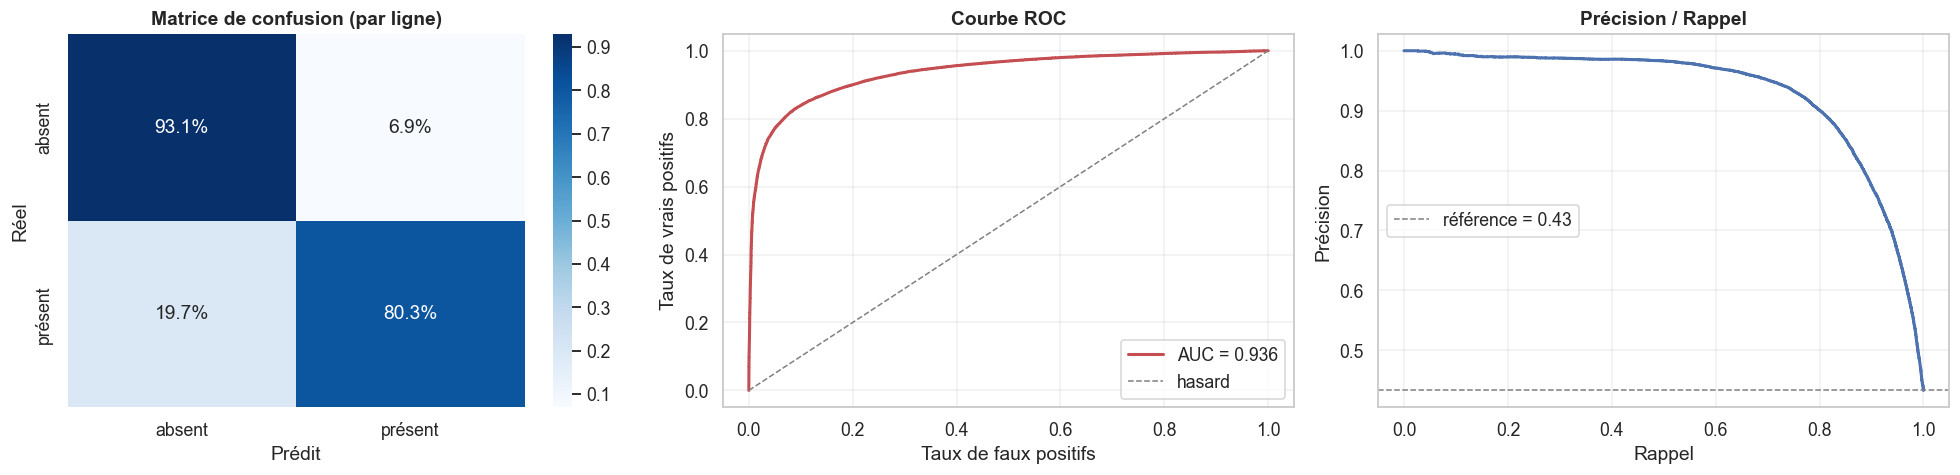

In [ ]:
# ── Analyse du meilleur modèle
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve)

best_nom = max((n for n in resultats if 'Référence' not in n),
               key=lambda n: resultats[n]['AUC'])
best = resultats[best_nom]['modele']
proba = best.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
print(f'Modèle retenu : {best_nom}\n')
print(classification_report(y_test, pred, target_names=['absent', 'présent'], digits=3))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

cm = confusion_matrix(y_test, pred, normalize='true')
sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues', ax=axes[0],
            xticklabels=['absent', 'présent'], yticklabels=['absent', 'présent'])
axes[0].set_title('Matrice de confusion (par ligne)', fontweight='bold')
axes[0].set_xlabel('Prédit'); axes[0].set_ylabel('Réel')

fpr, tpr, _ = roc_curve(y_test, proba)
axes[1].plot(fpr, tpr, lw=2, color='#C44E52',
             label=f'AUC = {resultats[best_nom]["AUC"]:.3f}')
axes[1].plot([0, 1], [0, 1], color='grey', lw=1, ls='--', label='hasard')
axes[1].set_xlabel('Taux de faux positifs'); axes[1].set_ylabel('Taux de vrais positifs')
axes[1].set_title('Courbe ROC', fontweight='bold'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

prec, rec, _ = precision_recall_curve(y_test, proba)
axes[2].plot(rec, prec, lw=2, color='#4C72B0')
axes[2].axhline(y_test.mean(), color='grey', lw=1, ls='--',
                label=f'référence = {y_test.mean():.2f}')
axes[2].set_xlabel('Rappel'); axes[2].set_ylabel('Précision')
axes[2].set_title('Précision / Rappel', fontweight='bold')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## 4. Ce que le modèle a appris

Deux lectures complémentaires : quelles variables comptent, et sur quelles
journées le modèle se trompe.


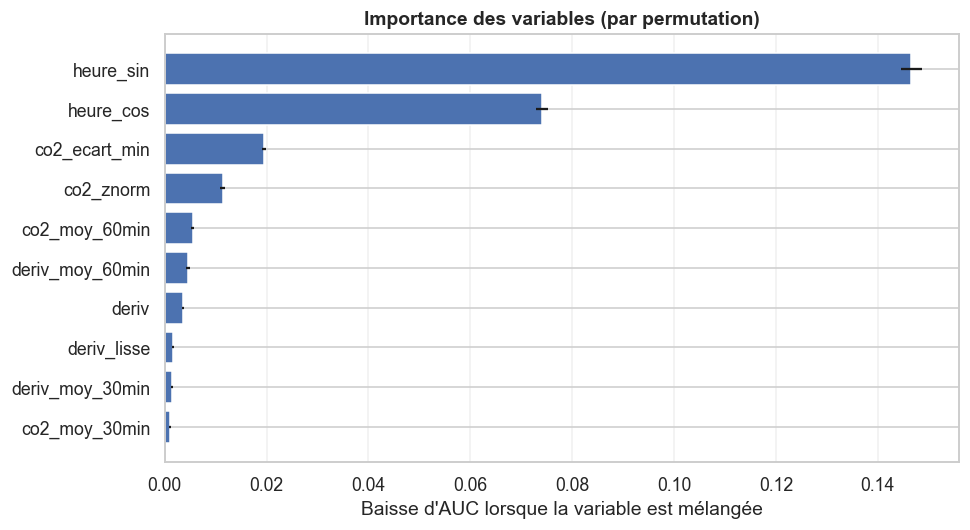

In [ ]:
# Importance par permutation : de combien l'AUC chute-t-elle si l'on mélange
# aléatoirement une variable ? Mesurée sur le test, donc sans biais d'apprentissage.
from sklearn.inspection import permutation_importance

sub = np.random.RandomState(42).choice(len(X_test), min(20_000, len(X_test)), replace=False)
imp = permutation_importance(best, X_test[sub], y_test[sub], n_repeats=5,
                             random_state=42, scoring='roc_auc')

ordre = np.argsort(imp.importances_mean)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh([FEATURES[i] for i in ordre], imp.importances_mean[ordre],
        xerr=imp.importances_std[ordre], color='#4C72B0')
ax.set_xlabel("Baisse d'AUC lorsque la variable est mélangée")
ax.set_title('Importance des variables (par permutation)', fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout(); plt.show()


AUC par journée — médiane : 0.981 · 1er quartile : 0.942 · 3e quartile : 0.996


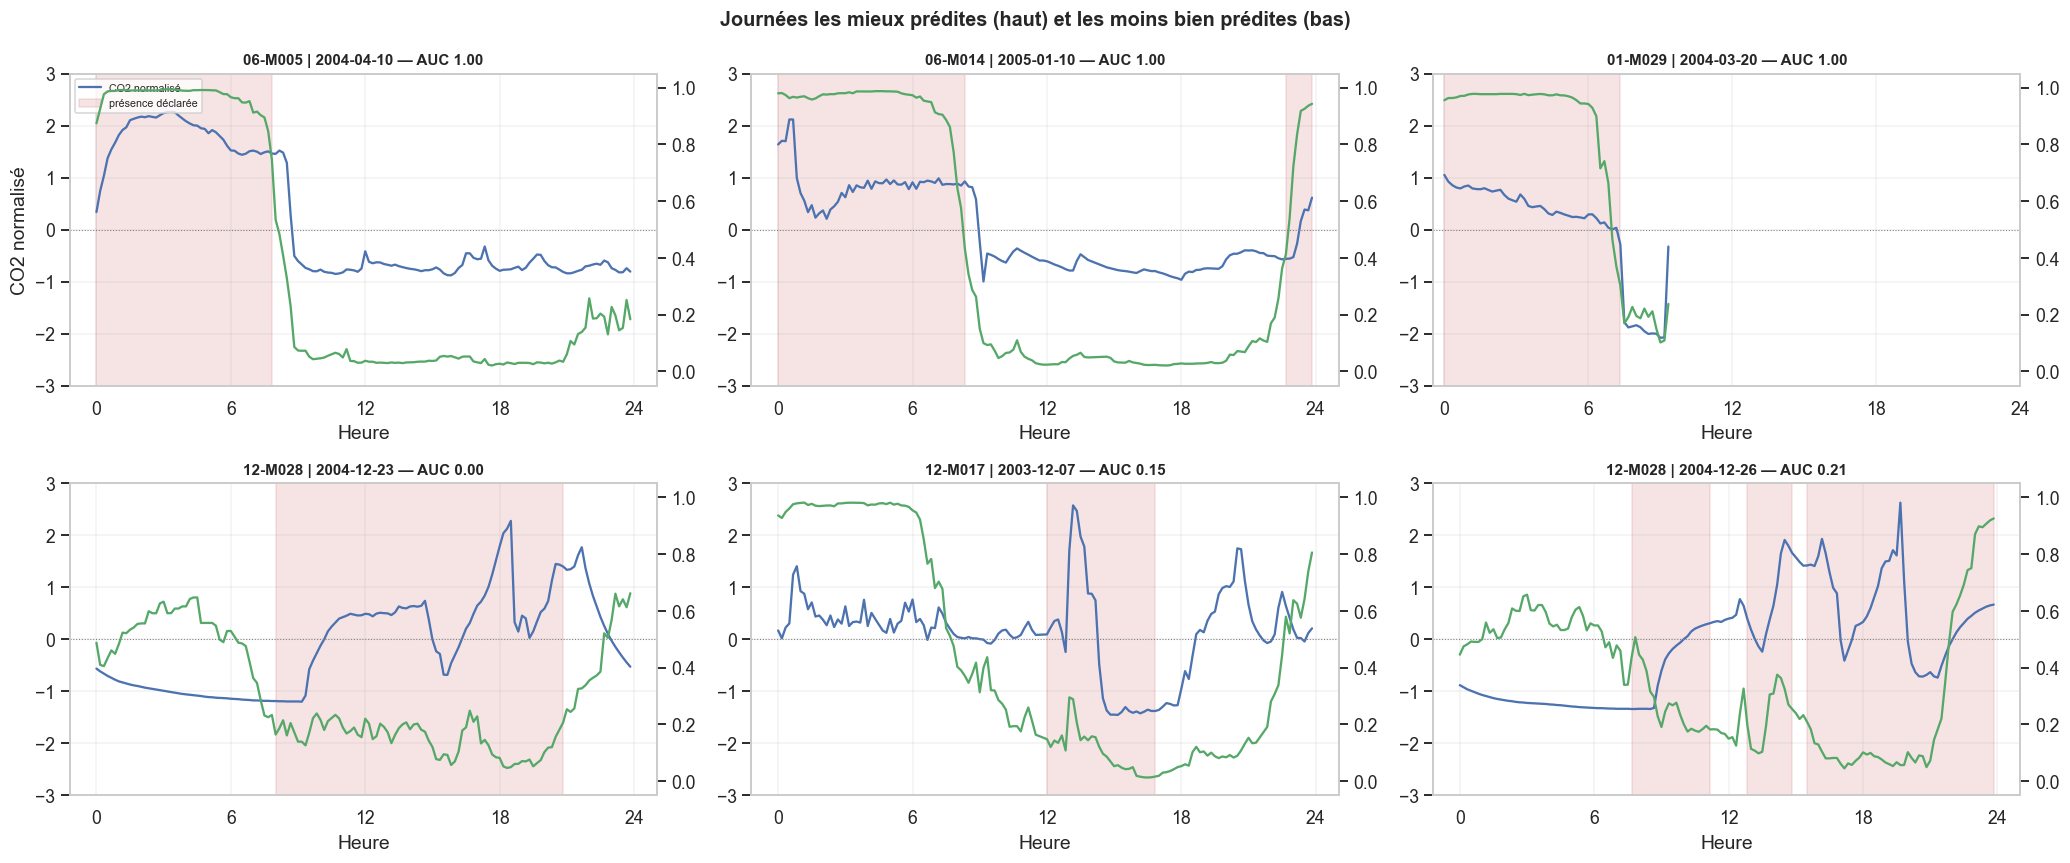

In [ ]:
# Journées de test : signal, présence réelle et probabilité prédite
test_ev = test.copy()
test_ev['proba'] = proba
perf_jour = (test_ev.groupby(['CODELIEU', 'DATE'])
             .apply(lambda x: roc_auc_score(x[CIBLE], x['proba'])
                    if x[CIBLE].nunique() > 1 else np.nan)
             .dropna().sort_values())

print(f'AUC par journée — médiane : {perf_jour.median():.3f} · '
      f'1er quartile : {perf_jour.quantile(.25):.3f} · '
      f'3e quartile : {perf_jour.quantile(.75):.3f}')

# Trois journées bien prédites, trois mal prédites
choix = list(perf_jour.tail(3).index) + list(perf_jour.head(3).index)
fig, axes = plt.subplots(2, 3, figsize=(19, 8))

for ax, (code_l, date_l) in zip(axes.ravel(), choix):
    j = test_ev[(test_ev['CODELIEU'] == code_l) & (test_ev['DATE'] == date_l)]
    ax.plot(j['heure'], j['co2_znorm'], color='#4C72B0', lw=1.5, label='CO2 normalisé')
    ax.fill_between(j['heure'], -3, 3, where=j[CIBLE], alpha=0.15,
                    color='#C44E52', label='présence déclarée')
    ax2 = ax.twinx()
    ax2.plot(j['heure'], j['proba'], color='#55A868', lw=1.5, label='probabilité prédite')
    ax2.axhline(0.5, color='grey', lw=0.7, ls=':')
    ax2.set_ylim(-0.05, 1.05); ax2.grid(False)
    ax.set_title(f'{code_l} | {date_l.date()} — AUC {perf_jour[(code_l, date_l)]:.2f}',
                 fontsize=10, fontweight='bold')
    ax.set_xticks([0, 6, 12, 18, 24]); ax.set_xlabel('Heure')
    ax.set_ylim(-3, 3); ax.grid(True, alpha=0.25)

axes[0, 0].set_ylabel('CO2 normalisé')
h1, l1 = axes[0, 0].get_legend_handles_labels()
axes[0, 0].legend(h1, l1, fontsize=7, loc='upper left')
plt.suptitle('Journées les mieux prédites (haut) et les moins bien prédites (bas)',
             fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


## 5. Que vaut le signal au-delà du rythme circadien ?

Une AUC élevée ne suffit pas à conclure. Le capteur étant en chambre dans 95 %
des logements, une règle triviale — « la nuit quelqu'un dort ici, la journée
non » — obtient déjà de bons résultats **sans jamais regarder le CO2**.

Il faut donc distinguer deux sources de performance :

- ce que l'**heure seule** permet de deviner (le rythme moyen des ménages) ;
- ce que le **signal ajoute** par-dessus.

C'est la seconde qui mesure la valeur réelle du CO2, et elle s'évalue *à heure
comparable* — sinon l'écart jour/nuit masque tout le reste.


Toutes les variables         AUC = 0.9365   (10 variable(s))
Signal seul (sans heure)     AUC = 0.8934   (8 variable(s))
Heure seule                  AUC = 0.9023   (2 variable(s))
CO2 normalisé seul           AUC = 0.8493   (1 variable(s))
Dérivées seules              AUC = 0.7060   (4 variable(s))


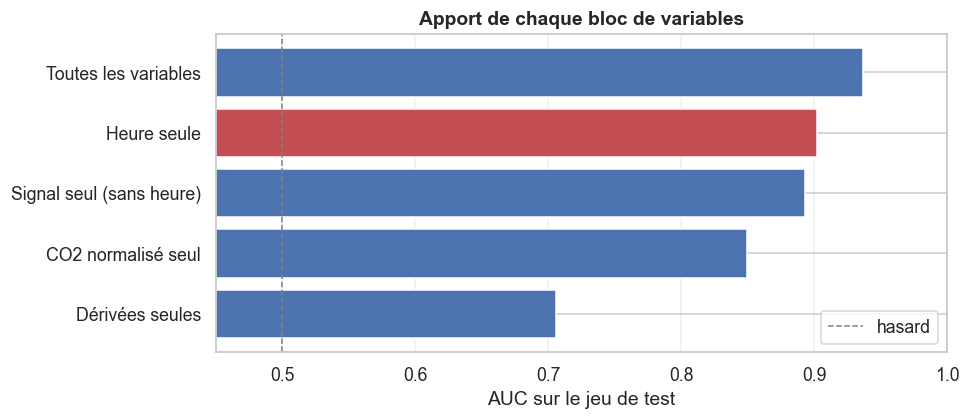


L'heure seule atteint 0.902 : une part importante de la performance globale
ne vient donc pas du signal, mais de la régularité du rythme jour / nuit.


In [ ]:
# ── Combien chaque bloc de variables apporte-t-il, seul et en combinaison ?
SIGNAL = [f for f in FEATURES if not f.startswith('heure')]
HEURE  = ['heure_sin', 'heure_cos']

blocs = {
    'Toutes les variables':      FEATURES,
    'Signal seul (sans heure)':  SIGNAL,
    'Heure seule':               HEURE,
    'CO2 normalisé seul':        ['co2_znorm'],
    'Dérivées seules':           [f for f in SIGNAL if 'deriv' in f],
}

scores = {}
for nom, feats in blocs.items():
    idx = [FEATURES.index(f) for f in feats]
    m = HistGradientBoostingClassifier(random_state=42).fit(X_train[:, idx], y_train)
    scores[nom] = roc_auc_score(y_test, m.predict_proba(X_test[:, idx])[:, 1])
    print(f'{nom:<28} AUC = {scores[nom]:.4f}   ({len(feats)} variable(s))')

fig, ax = plt.subplots(figsize=(9, 4))
s = pd.Series(scores).sort_values()
ax.barh(s.index, s.values, color=['#C44E52' if 'Heure seule' in i else '#4C72B0'
                                 for i in s.index])
ax.axvline(0.5, color='grey', lw=1, ls='--', label='hasard')
ax.set_xlim(0.45, 1.0); ax.set_xlabel('AUC sur le jeu de test')
ax.set_title("Apport de chaque bloc de variables", fontweight='bold')
ax.legend(); ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\nL'heure seule atteint {scores['Heure seule']:.3f} : une part importante "
      f"de la performance globale\nne vient donc pas du signal, mais de la "
      f"régularité du rythme jour / nuit.")


In [ ]:
# ── Gain du signal À HEURE COMPARABLE
# Deux modèles sont comparés créneau par créneau :
#   · le modèle COMPLET (10 variables, heure comprise), déjà entraîné en model_fit ;
#   · un modèle n'utilisant QUE l'heure, entraîné ci-dessous.
# À l'intérieur d'un créneau l'heure varie peu : l'écart entre les deux mesure
# donc ce que le signal apporte EN PLUS de l'heure, et non ce qu'il vaut seul.
m_heure = HistGradientBoostingClassifier(random_state=42)
m_heure.fit(X_train[:, [FEATURES.index(f) for f in HEURE]], y_train)

ev = test.copy()
ev['p_complet'] = proba
ev['p_heure'] = m_heure.predict_proba(X_test[:, [FEATURES.index(f) for f in HEURE]])[:, 1]
ev['creneau'] = pd.cut(ev['heure'], bins=[0, 4, 8, 12, 16, 20, 24], right=False,
                       labels=['0-4h', '4-8h', '8-12h', '12-16h', '16-20h', '20-24h'])

lignes = []
for cr, sub in ev.groupby('creneau', observed=True):
    y = sub[CIBLE].astype(int)
    if y.nunique() < 2:
        continue
    lignes.append({
        'créneau': cr,
        'présence réelle (%)': 100 * y.mean(),
        'AUC heure seule': roc_auc_score(y, sub['p_heure']),
        'AUC modèle complet': roc_auc_score(y, sub['p_complet']),
    })
gain = pd.DataFrame(lignes)
gain['gain'] = gain['AUC modèle complet'] - gain['AUC heure seule']
display(gain.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

x = np.arange(len(gain))
axes[0].bar(x - 0.2, gain['AUC heure seule'], 0.4, label='heure seule', color='#C44E52')
axes[0].bar(x + 0.2, gain['AUC modèle complet'], 0.4,
            label='heure + signal (modèle complet)', color='#4C72B0')
axes[0].axhline(0.5, color='grey', lw=1, ls='--')
axes[0].set_xticks(x); axes[0].set_xticklabels(gain['créneau'])
axes[0].set_ylabel('AUC'); axes[0].set_ylim(0.4, 1.0)
axes[0].set_title('Pouvoir de discrimination par créneau', fontweight='bold')
axes[0].legend(); axes[0].grid(True, axis='y', alpha=0.3)

axes[1].bar(gain['créneau'], gain['gain'], color='#55A868')
axes[1].set_ylabel("Gain d'AUC apporté par le signal(au-delà de l'heure)")
axes[1].set_title('Apport du CO2 au-delà de l\'heure', fontweight='bold')
axes[1].grid(True, axis='y', alpha=0.3)
ax2 = axes[1].twinx()
ax2.plot(gain['créneau'], gain['présence réelle (%)'], color='#333333',
         marker='o', lw=1.5, label='présence réelle')
ax2.set_ylabel('Présence réelle (%)'); ax2.grid(False); ax2.legend(loc='upper right')

plt.tight_layout(); plt.show()


In [ ]:
# ── Cas difficile : détecter le MOMENT du changement
# Repérer qu'une pièce est occupée est une chose ; repérer l'instant précis de
# l'arrivée ou du départ en est une autre. On isole la première heure de chaque
# plage (de présence comme d'absence) pour l'évaluer.
ev = ev.sort_values(['CODELIEU', 'DATE', 'tranche'])
plage = ev.groupby(['CODELIEU', 'DATE'])[CIBLE].transform(lambda s: s.ne(s.shift()).cumsum())
ev['debut_plage'] = ev.groupby(['CODELIEU', 'DATE', plage]).cumcount() < 6   # 6 × 10 min

tr = ev[ev['debut_plage']]
y_tr = tr[CIBLE].astype(int)
print(f'{len(tr):,} observations en début de plage ({len(tr)/len(ev)*100:.0f}% du test)\n')
print(f"  AUC heure seule  : {roc_auc_score(y_tr, tr['p_heure']):.3f}")
print(f"  AUC avec signal  : {roc_auc_score(y_tr, tr['p_complet']):.3f}")
print(f"\nÀ comparer au gain obtenu sur l'ensemble des observations "
      f"({roc_auc_score(ev[CIBLE].astype(int), ev['p_complet']) - roc_auc_score(ev[CIBLE].astype(int), ev['p_heure']):+.3f}).")


16,839 observations en début de plage (16% du test)

  AUC heure seule  : 0.718
  AUC avec signal  : 0.767

À comparer au gain obtenu sur l'ensemble des observations (+0.034).


**Lecture** — deux effets se superposent et doivent être distingués :

- L'AUC globale élevée tient **en partie** à la régularité du rythme jour/nuit,
  que l'heure seule capte déjà. Annoncer ce chiffre sans le préciser serait
  trompeur.
- Mais **à heure comparable**, le signal apporte un gain net, et le plus fort
  là où l'heure devient muette : en pleine nuit et en milieu de journée, quand
  savoir « il est 2 h » ou « il est 14 h » ne suffit plus à trancher entre les
  logements occupés et les autres.

C'est ce second point qui constitue le résultat : **le CO2 renseigne sur
l'occupation au-delà de ce que le rythme moyen laisse deviner**.

La détection des *transitions* reste en revanche nettement plus difficile — le
CO2 met du temps à s'accumuler comme à se dissiper, ce qui rend l'instant précis
d'une arrivée ou d'un départ intrinsèquement flou dans ce signal.


## 6. Synthèse

**Le CO2 permet-il de retrouver l'occupation ?** — Oui, mais l'énoncé demande
une précision. L'AUC globale bénéficie de la forte régularité du rythme
jour/nuit, que l'heure seule suffit à capter. La mesure honnête est le **gain à
heure comparable**, positif sur tous les créneaux et maximal quand l'heure ne
discrimine plus (nuit profonde, milieu de journée).

**Quelle grandeur porte l'information ?** — Le **niveau** de CO2 normalisé par
logement, nettement plus que sa dérivée. C'est un point à souligner : la dérivée
met en évidence les *événements*, mais c'est l'accumulation qui traduit la
*présence*.

**Où le modèle échoue-t-il ?** — Sur les transitions. Le CO2 s'accumule et se
dissipe lentement : l'instant exact d'une arrivée ou d'un départ est
intrinsèquement mal défini dans ce signal, indépendamment du modèle employé.

**Limites** — La vérité terrain est *déclarative* : le semainier est rempli de
mémoire, avec les approximations que cela suppose (arrondi des horaires, oublis).
Une part de l'erreur mesurée relève probablement de la déclaration et non du
signal, ce qui rend les scores obtenus plutôt conservateurs.

**Suites possibles** — étendre à la cible `dans_logement` (présence n'importe où
plutôt que dans la seule pièce du capteur) ; ajouter température et humidité,
mesurées par la même sonde ; estimer le *nombre* d'occupants plutôt que leur
seule présence.
